# Retail Customer Behaviour Analysis
## Notebook 1 — Exploratory Data Analysis (EDA)

Goal: Answer 6 business questions using Python
Dataset: 3,900 customer transactions, 18 columns, $233K total revenue
Tools: numpy, pandas, matplotlib, seaborn

In [3]:
# Section 1: Import Libraries & Load Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/shopping_behavior_updated.csv')

## Section 1 — Libraries Imported and Data Loaded

Dataset loaded from data/shopping_behavior_updated.csv
All libraries confirmed working. Ready for initial exploration.

## Section 2 — Initial Data Exploration

Before any analysis, we inspect the dataset structure, data types,
and basic statistics to understand what we are working with.

In [4]:
# Shape of dataset
print("Shape:",df.shape)

# Column names
print("\ncolumns:",df.columns.tolist())

# Data types
print("\nData type:")
print(df.dtypes)

Shape: (3900, 18)

columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

Data type:
Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object


In [6]:
# first 5 rows
df.head()



,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [7]:
# Basic statistics
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## Section 2.1 — Data Quality Audit

A structured audit of each column to confirm data types, 
unique values, and missing counts before analysis.

In [9]:
# Data quality audit table
audit = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Missing_Count': df.isnull().sum().values,
    'Action_Taken': ['No action required'] * len(df.columns)
})

print(audit.to_string(index=False))

                Column   Dtype  Unique_Values  Missing_Count       Action_Taken
           Customer ID   int64           3900              0 No action required
                   Age   int64             53              0 No action required
                Gender     str              2              0 No action required
        Item Purchased     str             25              0 No action required
              Category     str              4              0 No action required
 Purchase Amount (USD)   int64             81              0 No action required
              Location     str             50              0 No action required
                  Size     str              4              0 No action required
                 Color     str             25              0 No action required
                Season     str              4              0 No action required
         Review Rating float64             26              0 No action required
   Subscription Status     str          

In [10]:
# Check for duplicates customer IDs
duplicates = df[df.duplicated('Customer ID')]
print("Duplicate Customer IDs found;", len(duplicates))

Duplicate Customer IDs found; 0


In [11]:
# Standardize column names for MySQL compatibility
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'}, inplace=True)

print("Updated Columns:")
print(df.columns.tolist())

Updated Columns:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


### Observation

Dataset contains 3,900 rows and 18 columns — 4 numerical, 14 categorical.
Zero missing values found across all columns.
No duplicate Customer IDs detected.
Column names standardized to lowercase with underscores for MySQL compatibility.

## Section 3 — Univariate Analysis

Analyzing individual columns to understand distribution 
of key variables before comparing them against each other.

### 3.1 — Purchase Amount Distribution

Checking if purchase amounts are normally distributed 
or skewed — this affects our AOV analysis.

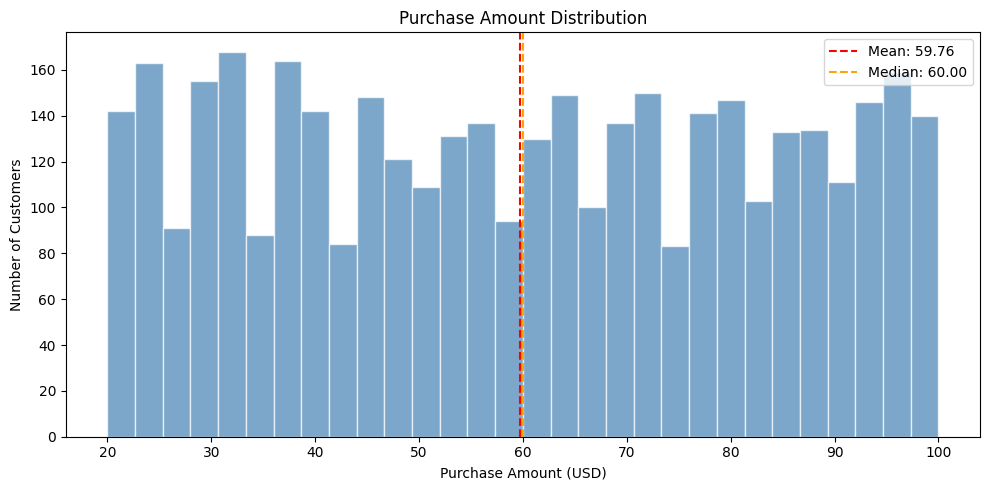

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['purchase_amount'], bins=30, 
        color='steelblue', edgecolor='white', alpha=0.7)

ax.axvline(df['purchase_amount'].mean(), 
           color='red', linestyle='--', label=f"Mean: {df['purchase_amount'].mean():.2f}")
ax.axvline(df['purchase_amount'].median(), 
           color='orange', linestyle='--', label=f"Median: {df['purchase_amount'].median():.2f}")

ax.set_title('Purchase Amount Distribution')
ax.set_xlabel('Purchase Amount (USD)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

### Observation

Purchase amounts are uniformly distributed between $20 and $100.
Mean and median are nearly identical at ~$59.76 — no skew present.
No extreme outliers detected. This suggests a flat pricing strategy 
with no premium tier differentiation.

### 3.2 — Customer Age Distribution

Understanding the age spread helps identify 
which demographic to prioritize in recommendations.

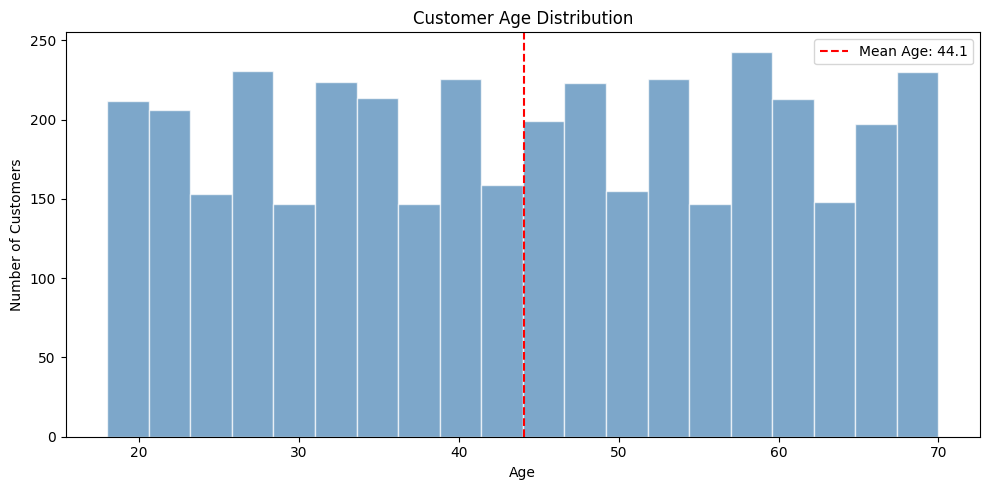

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['age'], bins=20, 
        color='steelblue', edgecolor='white', alpha=0.7)

ax.axvline(df['age'].mean(), 
           color='red', linestyle='--', label=f"Mean Age: {df['age'].mean():.1f}")

ax.set_title('Customer Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

### Observation

Customer age ranges from 18 to 70 years with mean age of 44.1.
Distribution is relatively uniform — no single age group dominates.
Detailed age group revenue analysis will be done in Section 4.


### 3.3 — Product Category Distribution

Identifying which category has the most orders 
— order count vs revenue can differ significantly.

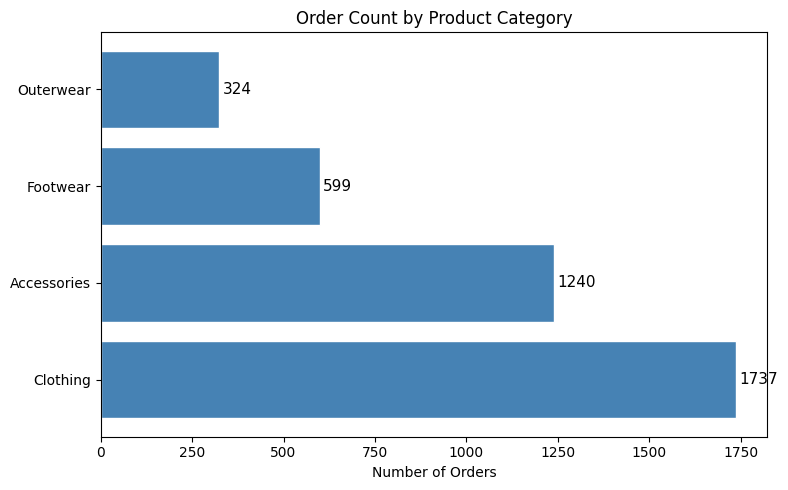

In [14]:
category_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(category_counts.index, category_counts.values, 
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, category_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
            str(val), va='center', fontsize=11)

ax.set_title('Order Count by Product Category')
ax.set_xlabel('Number of Orders')
plt.tight_layout()
plt.show()

### Observation

Clothing dominates with 1,737 orders (44.5%) followed by 
Accessories with 1,240 orders (31.8%).
High order count does not always mean high revenue — 
this will be cross-checked in bivariate analysis.

## Section 4 — Bivariate Analysis

Comparing variables against each other to identify 
relationships that answer our core business questions.

### 4.1 — Revenue by Product Category

Order count alone does not tell the full story.
Comparing actual revenue per category reveals true business value.

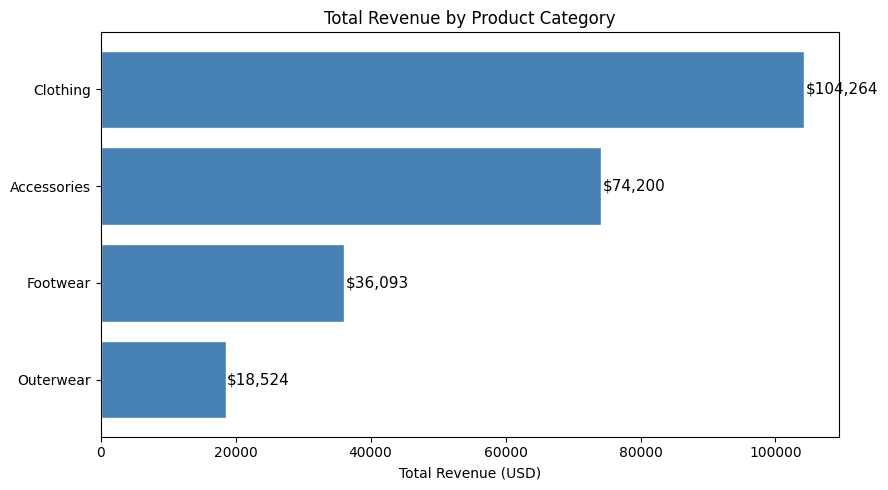

In [15]:
category_revenue = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(category_revenue.index, category_revenue.values,
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, category_revenue.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11)

ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

### Observation

Clothing leads revenue at $104,264 (44.7%) despite having the most orders.
Accessories at $74,200 despite fewer orders than Clothing.
Outerwear contributes only $18,524 — lowest revenue and lowest order count.
High order count in Clothing confirms it is both the most purchased 
and highest revenue category.

### 4.2 — Revenue by Age Group

Creating age groups to identify which demographic 
drives the most revenue for the business.

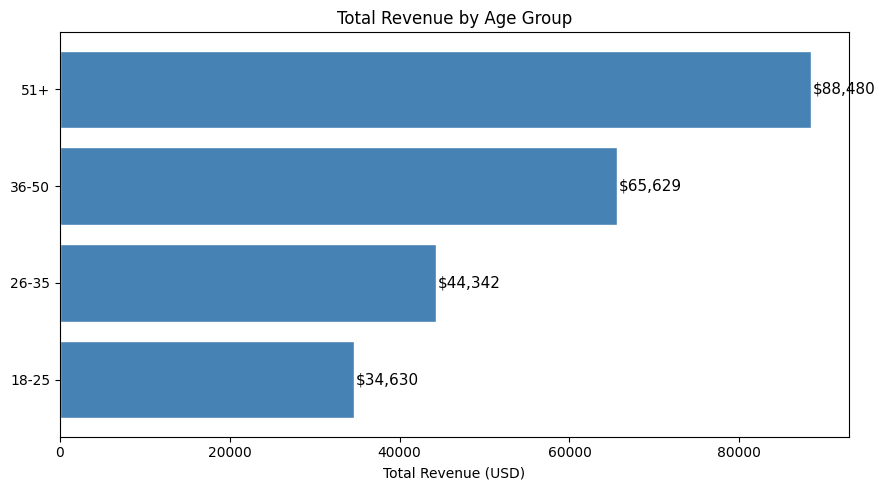

In [16]:
df['age_group'] = pd.cut(df['age'], 
                          bins=[17, 25, 35, 50, 70],
                          labels=['18-25', '26-35', '36-50', '51+'])

age_revenue = df.groupby('age_group', observed=True)['purchase_amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(age_revenue.index.astype(str), age_revenue.values,
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, age_revenue.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11)

ax.set_title('Total Revenue by Age Group')
ax.set_xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

### Observation

51+ age group contributes $88,480 — 38% of total revenue, highest of all groups.
18-25 group contributes least at $34,630 (14.8%).
Revenue advantage of 51+ is volume-driven, not spend-driven — 
average purchase amount is nearly equal across all age groups.

### 4.3 — Discount Impact on Average Order Value

Testing whether discounts actually drive higher spending — 
a common business assumption that may not hold true.

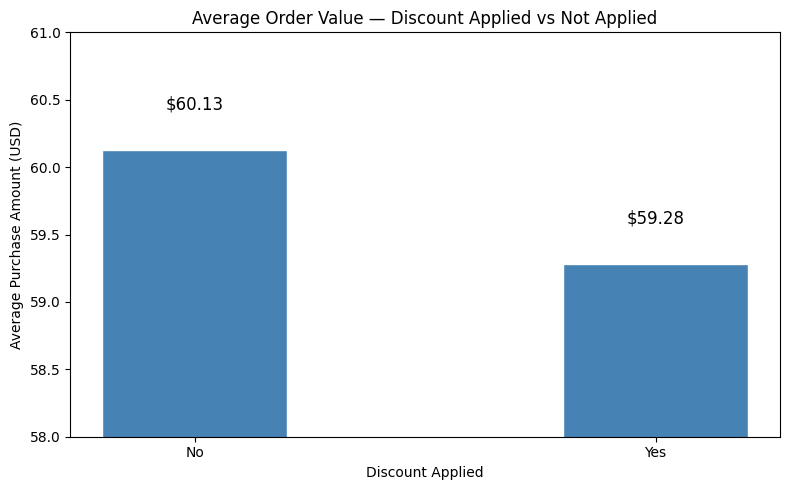

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

discount_avg = df.groupby('discount_applied')['purchase_amount'].mean()

bars = ax.bar(discount_avg.index, discount_avg.values,
              color='steelblue', edgecolor='white', width=0.4)

for bar, val in zip(bars, discount_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', fontsize=12)

ax.set_title('Average Order Value — Discount Applied vs Not Applied')
ax.set_xlabel('Discount Applied')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.set_ylim(58, 61)
plt.tight_layout()
plt.show()

### Observation

Discounted orders average $59.28 vs non-discounted $60.13.
Discounts are reducing AOV by $0.85 per order — not increasing it.
This challenges the standard assumption that discounts drive higher spend.
Business is losing margin without gaining volume benefit.

### 4.4 — Subscription Status vs Average Spend

Checking whether subscribers are higher-value customers 
or whether subscription benefits are non-monetary.

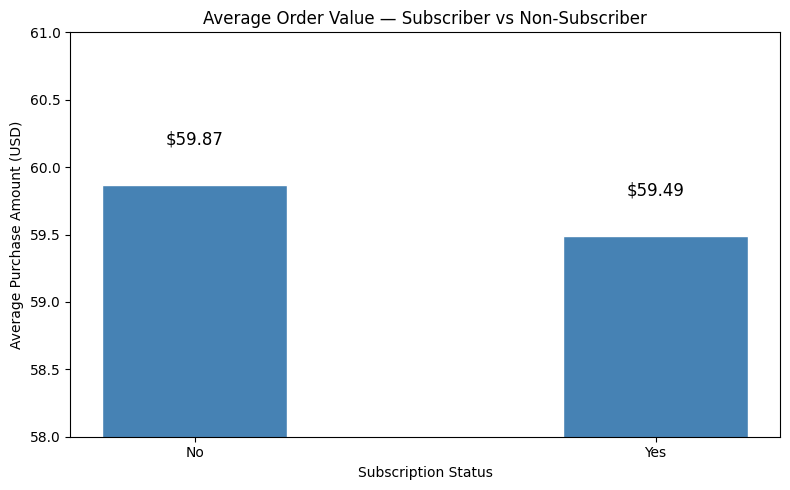

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

sub_avg = df.groupby('subscription_status')['purchase_amount'].mean()

bars = ax.bar(sub_avg.index, sub_avg.values,
              color='steelblue', edgecolor='white', width=0.4)

for bar, val in zip(bars, sub_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', fontsize=12)

ax.set_title('Average Order Value — Subscriber vs Non-Subscriber')
ax.set_xlabel('Subscription Status')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.set_ylim(58, 61)
plt.tight_layout()
plt.show()

### Observation

Subscribers average $59.49 vs non-subscribers $59.87 — virtually no difference.
Subscription is likely driven by operational benefits such as free shipping 
or priority access, not by higher spending behavior.
This means current subscription messaging may be targeting the wrong value proposition.

### 4.5 — Revenue by Gender

Comparing total revenue and per-customer spend across genders 
to avoid misleading conclusions from raw totals alone.

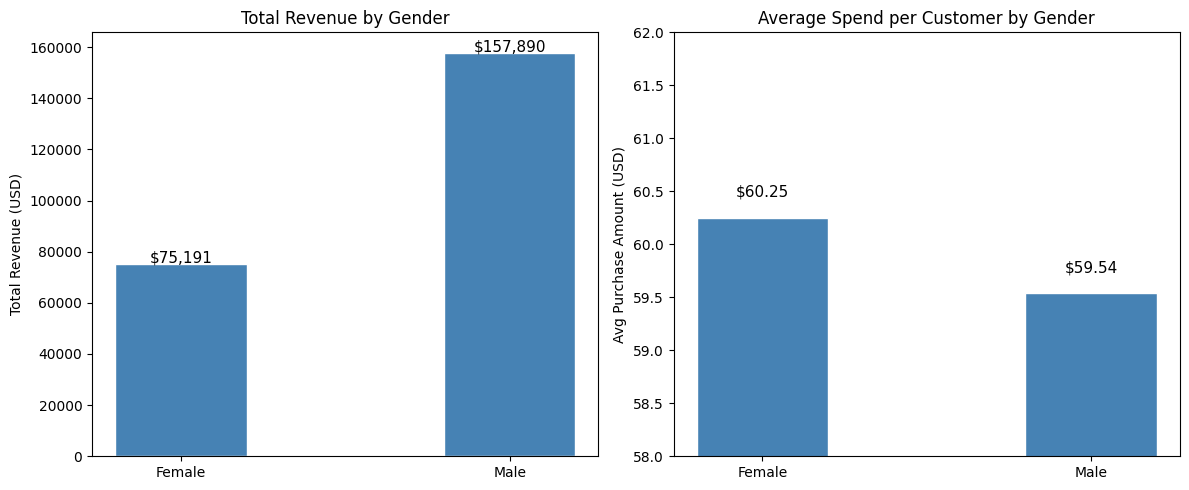

In [19]:
gender_data = df.groupby('gender').agg(
    total_revenue=('purchase_amount', 'sum'),
    customer_count=('purchase_amount', 'count'),
    avg_spend=('purchase_amount', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total Revenue
bars1 = axes[0].bar(gender_data['gender'], gender_data['total_revenue'],
                     color='steelblue', edgecolor='white', width=0.4)
for bar, val in zip(bars1, gender_data['total_revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val:,.0f}', ha='center', fontsize=11)
axes[0].set_title('Total Revenue by Gender')
axes[0].set_ylabel('Total Revenue (USD)')

# Avg Spend
bars2 = axes[1].bar(gender_data['gender'], gender_data['avg_spend'],
                     color='steelblue', edgecolor='white', width=0.4)
for bar, val in zip(bars2, gender_data['avg_spend']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'${val:.2f}', ha='center', fontsize=11)
axes[1].set_title('Average Spend per Customer by Gender')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
axes[1].set_ylim(58, 62)

plt.tight_layout()
plt.show()

### Observation

Male customers contribute $157,890 (67.7%) vs Female $75,191 (32.3%) in total revenue.
However, average spend per customer is nearly identical across both genders.
Revenue gap is entirely due to male customers being 2.1x more in count — 
not because males spend more per order.
Targeting female customers for acquisition could significantly close this gap.

### 4.6 — Correlation Heatmap — Numerical Variables

Checking if any numerical variables are strongly 
correlated with purchase amount.

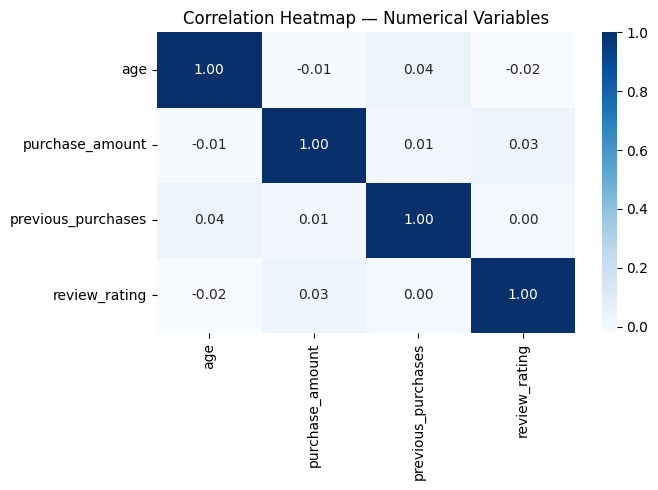

In [20]:
numerical_cols = df[['age', 'purchase_amount', 'previous_purchases', 'review_rating']]

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(numerical_cols.corr(), 
            annot=True, 
            fmt='.2f',
            cmap='Blues',
            ax=ax)

ax.set_title('Correlation Heatmap — Numerical Variables')
plt.tight_layout()
plt.show()

### Observation

All numerical variables show weak correlation with purchase amount.
Age, review rating, and previous purchases have near-zero correlation 
with spending behavior.
This confirms that purchase decisions are driven by categorical factors 
such as category, season, and discount — not demographics.

### 4.7 Promo Code vs Discount — Combined Impact

This dataset contains both Promo Code and Discount columns.
Comparing their individual impact on AOV reveals whether 
these two promotional tools behave differently.

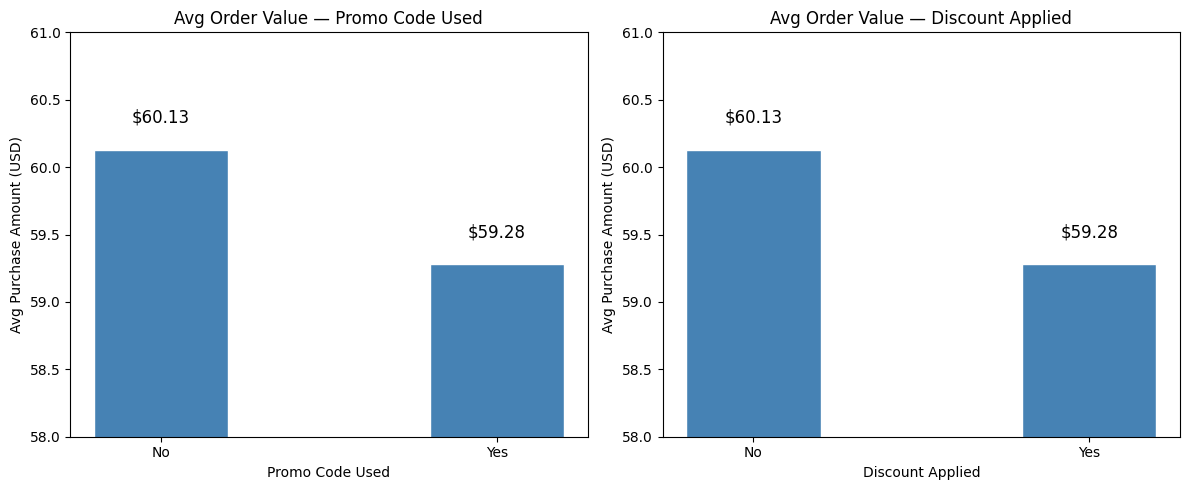

In [22]:
promo_avg = df.groupby('promo_code_used')['purchase_amount'].mean()
discount_avg = df.groupby('discount_applied')['purchase_amount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(promo_avg.index, promo_avg.values,
            color='steelblue', edgecolor='white', width=0.4)
for i, val in enumerate(promo_avg.values):
    axes[0].text(i, val + 0.2, f'${val:.2f}', ha='center', fontsize=12)
axes[0].set_title('Avg Order Value — Promo Code Used')
axes[0].set_xlabel('Promo Code Used')
axes[0].set_ylabel('Avg Purchase Amount (USD)')
axes[0].set_ylim(58, 61)

axes[1].bar(discount_avg.index, discount_avg.values,
            color='steelblue', edgecolor='white', width=0.4)
for i, val in enumerate(discount_avg.values):
    axes[1].text(i, val + 0.2, f'${val:.2f}', ha='center', fontsize=12)
axes[1].set_title('Avg Order Value — Discount Applied')
axes[1].set_xlabel('Discount Applied')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
axes[1].set_ylim(58, 61)

plt.tight_layout()
plt.show()

### Observation

Both promo code and discount show identical negative impact on AOV.
Promo code used: $59.28 avg vs not used: $60.13 avg.
Discount applied: $59.28 avg vs not applied: $60.13 avg.
Both promotional tools are behaving the same way — 
neither is driving higher spend. Promotional strategy needs rethinking.

## Section 5 — Export Cleaned Dataset

Exporting the cleaned and standardized dataset for MySQL import.
Column names have been standardized to lowercase with underscores.

In [21]:
df.to_csv('../data/cleaned_shopping_data.csv', index=False)

print("Cleaned dataset exported successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned dataset exported successfully.
Shape: (3900, 19)
Columns: ['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases', 'age_group']


### Export Complete

cleaned_shopping_data.csv saved to data/ folder.
Ready for import into MySQL for Phase 3 SQL analysis.